#### Project Overview:
**- Task:** predict a number of a handwritten image

**- Train dataset:** MNIST: http://yann.lecun.com/exdb/mnist/ (train: 60k samples, test: 10k samples)

**- Feature types:** 28x28 pixels

**- Output:** predicted number

**- Pipeline:**\
(1) data setup and preprocessing\
(2) data analysis\
(3) train the DNN model\
(4) evaluate the model

In [79]:
import torchvision
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

##### 1. Data setup and preprocessing

In [80]:
# download the dataset
image_path = './data'

transform = transforms.Compose([
    transforms.ToTensor(),
])

mnist_train_dataset = torchvision.datasets.MNIST(
    root=image_path,
    transform=transform,
    train=True,
    download=True
)

mnist_test_dataset = torchvision.datasets.MNIST(
    root=image_path,
    transform=transform,
    train=False,
    download=True
)

In [81]:
len(mnist_train_dataset)

60000

In [82]:
# create data loader
batch_size = 512
train_dl = DataLoader(mnist_train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

##### 2. Data analysis

In [83]:
# check sample shape
sample = train_dl.dataset[0]
print("feature shape: ", sample[0].shape)
print("label: ", sample[1])
print("number of class: ", len(torch.unique(mnist_test_dataset.targets)), 
      " - ", *torch.unique(mnist_test_dataset.targets).numpy())

feature shape:  torch.Size([1, 28, 28])
label:  5
number of class:  10  -  0 1 2 3 4 5 6 7 8 9


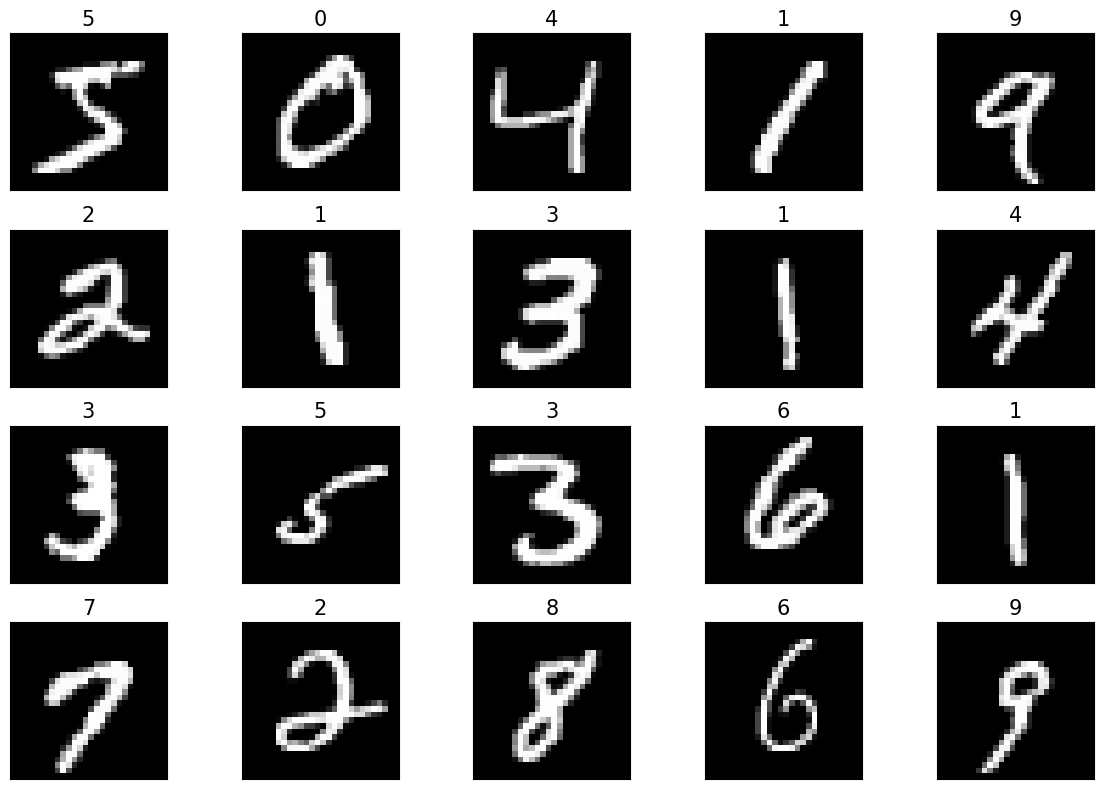

In [84]:
# visualize the image:
from itertools import islice
fig = plt.figure(figsize=(12, 8))

for i, (image, label) in islice(enumerate(mnist_train_dataset), 20):
    ax = fig.add_subplot(4, 5, i+1)
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_xticks([]), ax.set_yticks([])
    ax.set_title(label, size=15)

plt.tight_layout()
plt.show()

#### 3. Train the model

In [85]:
# create model
image_size = mnist_train_dataset[0][0].shape
input_size = image_size[0] * image_size[1] * image_size[2]
output_size = 10
hidden_units = [256, 128, 64]

all_layers = [nn.Flatten()] # flatten the image 1x28x28

for hidden_unit in hidden_units:
    all_layers.append(nn.Linear(input_size, hidden_unit))
    all_layers.append(nn.ReLU())
    input_size = hidden_unit

all_layers.append(nn.Linear(input_size, output_size))
model = nn.Sequential(*all_layers)
model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=64, bias=True)
  (6): ReLU()
  (7): Linear(in_features=64, out_features=10, bias=True)
)

In [86]:
# create loss function and optimizer
loss_fn = nn.CrossEntropyLoss()

lr = 1e-3
optimizer = torch.optim.Adam(lr=lr, params=model.parameters())

In [87]:
# train the model
n_epochs = 100
torch.manual_seed(1)

train_loss_hist = []
train_accuracy_hist = []

for epoch in range(n_epochs):
    epoch_loss = 0
    epoch_accuracy = 0

    for x_batch, y_batch in train_dl:
        # forward
        y_pred = model.forward(x_batch)

        # loss
        loss = loss_fn(y_pred, y_batch)
        loss.backward() # compute gradients

        # update w, b 
        optimizer.step()
        optimizer.zero_grad()

        # tracking
        epoch_loss += loss.item()
        epoch_accuracy += (torch.argmax(y_pred, dim=1) == y_batch).float().mean().item()
    
    train_loss_hist.append(epoch_loss/len(train_dl))
    train_accuracy_hist.append(epoch_accuracy/len(train_dl))

    if (epoch+1)%10 == 0:
        print(f"Epoch {epoch+1}: Loss: {epoch_loss/len(train_dl):.4f}, "
              f"Accuracy: {epoch_accuracy/len(train_dl):.4f}")

Epoch 10: Loss: 0.0394, Accuracy: 0.9882
Epoch 20: Loss: 0.0085, Accuracy: 0.9978
Epoch 30: Loss: 0.0004, Accuracy: 1.0000
Epoch 40: Loss: 0.0001, Accuracy: 1.0000
Epoch 50: Loss: 0.0001, Accuracy: 1.0000
Epoch 60: Loss: 0.0000, Accuracy: 1.0000
Epoch 70: Loss: 0.0000, Accuracy: 1.0000
Epoch 80: Loss: 0.0000, Accuracy: 1.0000
Epoch 90: Loss: 0.0000, Accuracy: 1.0000
Epoch 100: Loss: 0.0000, Accuracy: 1.0000


##### 5. Evaluation

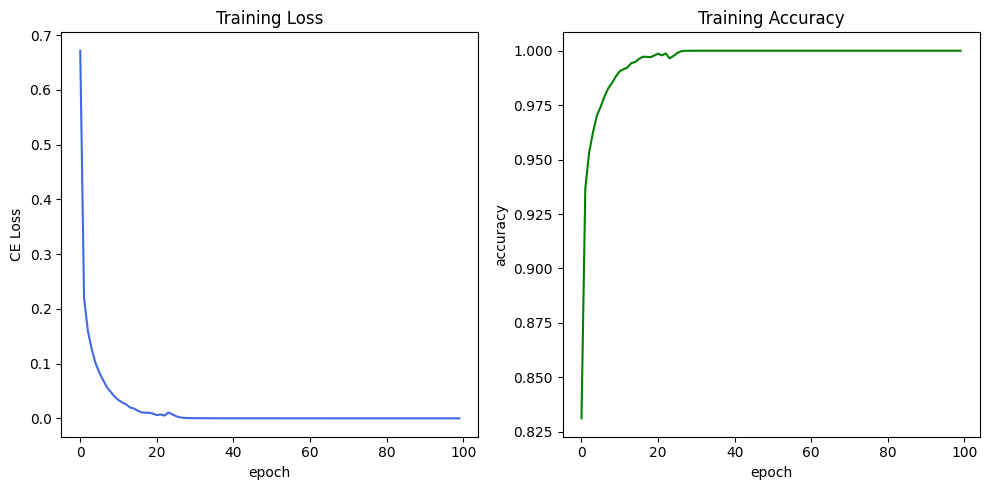

In [88]:
# plot training curve
fig = plt.figure(figsize=(10, 5))

ax_1 = fig.add_subplot(1, 2, 1)
ax_1.plot(train_loss_hist, label="Traning Loss", color="royalblue")
ax_1.set_xlabel("epoch")
ax_1.set_ylabel("CE Loss")
ax_1.set_title("Training Loss")

ax_2 = fig.add_subplot(1, 2, 2)
ax_2.plot(train_accuracy_hist, label="Traning Loss", color="green")
ax_2.set_xlabel("epoch")
ax_2.set_ylabel("accuracy")
ax_2.set_title("Training Accuracy")

plt.tight_layout()
plt.show()


In [90]:
# evaluate the model on test set
test_dl = DataLoader(mnist_test_dataset, batch_size=1024)

accuracy = 0
with torch.no_grad():
    for x_batch, y_batch in test_dl:
        y_preds = model.forward(x_batch)
        accuracy += (torch.argmax(y_preds, dim=1)==y_batch).float().mean()*len(y_batch)

print(f"accuracy: {accuracy/len(test_dl.dataset)*100:.2f}%")
    

accuracy: 98.00%
